In [10]:
# === STEP 1: Import Libraries ===
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
# === STEP 2: Connect to the Database ===
conn = sqlite3.connect("stackoverflow.db")

In [3]:
# === STEP 3: Load and Preview 'users' Table === 11m
users_df = pd.read_sql_query("SELECT * FROM users", conn)

In [4]:
# Show basic info
print(f"Number of rows in 'users': {len(users_df)}")
print(users_df.head())
print(users_df.dtypes)

Number of rows in 'users': 22484235
     Id  Reputation             CreationDate         DisplayName  \
0 -1017           1  2023-09-15T20:10:32.247  Mobile Development   
1 -1016           1  2023-06-28T20:22:59.967                 PHP   
2 -1015           1  2023-06-28T18:50:43.493                 NLP   
3 -1014           1  2023-02-17T19:52:56.213          R Language   
4 -1013           1  2023-02-17T19:25:19.953               CI/CD   

            LastAccessDate                                            AboutMe  \
0  2023-09-15T20:10:32.290  <p>A collective for developers who want to sha...   
1  2023-06-28T20:22:59.980  <p>A collective where developers working with ...   
2  2023-06-28T18:50:43.527  <p>A collective focused on NLP (natural langua...   
3  2023-02-17T19:52:56.280  <p>A collective where data scientists and AI r...   
4  2023-02-17T19:25:20.037  <p>A collective where developers focused on co...   

   Views  UpVotes  DownVotes  
0      0        0          0  
1     

In [5]:
# === STEP 4: Data Cleaning ===

# Convert date columns to datetime
users_df["CreationDate"] = pd.to_datetime(users_df["CreationDate"], errors="coerce")
users_df["LastAccessDate"] = pd.to_datetime(users_df["LastAccessDate"], errors="coerce")

In [6]:
# Drop rows with invalid or missing CreationDate 8m
users_df = users_df.dropna(subset=["CreationDate"])

In [7]:
# Drop any duplicate user IDs 3m
users_df = users_df.drop_duplicates(subset=["Id"])

In [12]:
# Count rows before next cell code, so to see how many future dated CreationDate will be removed
before = len(users_df)
before

22484235

In [11]:
# Remove users with future creation dates 3m
users_df = users_df[users_df["CreationDate"] <= pd.Timestamp(datetime.today())]

In [13]:
# Count after
after = len(users_df)
print(f"Removed {before - after} users with future creation dates.")

Removed 0 users with future creation dates.


In [21]:
# === STEP 5: Feature Engineering for Month === 31s

# Extract year-month for grouping
users_df["YearMonth"] = users_df["CreationDate"].dt.to_period("M").astype(str)

In [17]:
# # === Updated STEP 5: Extract Year ===
# users_df["Year"] = users_df["CreationDate"].dt.year

In [22]:
# === STEP 6: Group by Year-Month and Count New Users ===
df = users_df.groupby("YearMonth").size().reset_index(name="count")

In [15]:
# # === STEP 6: Count New Users Per Month ===
# monthly_new_users = users_df["YearMonth"].value_counts().sort_index()

In [18]:
# # === STEP 6: Count New Users Per Year ===
# yearly_users = users_df.groupby("Year").size().reset_index(name="NewUsers")

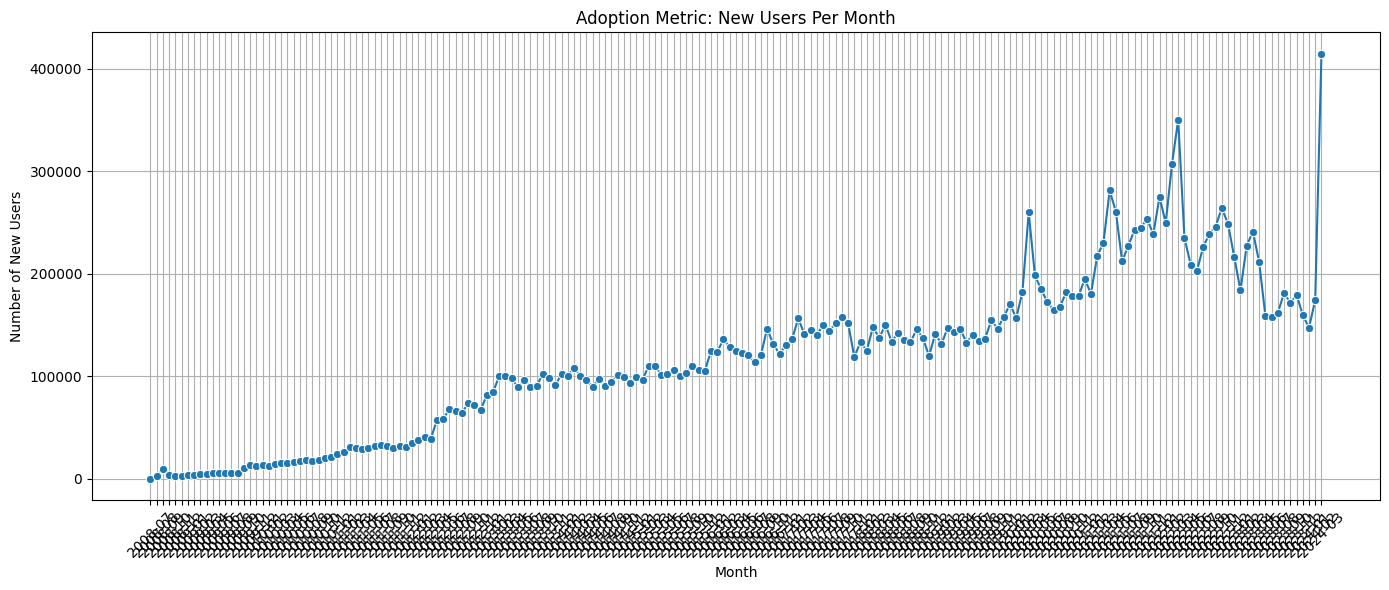

In [16]:
# # === STEP 7: Plot Adoption Metric ===
# plt.figure(figsize=(14, 6))
# sns.lineplot(x=monthly_new_users.index, y=monthly_new_users.values, marker="o")
# plt.xticks(rotation=45)
# plt.title("Adoption Metric: New Users Per Month")
# plt.xlabel("Month")
# plt.ylabel("Number of New Users")
# plt.tight_layout()
# plt.grid(True)
# plt.show()

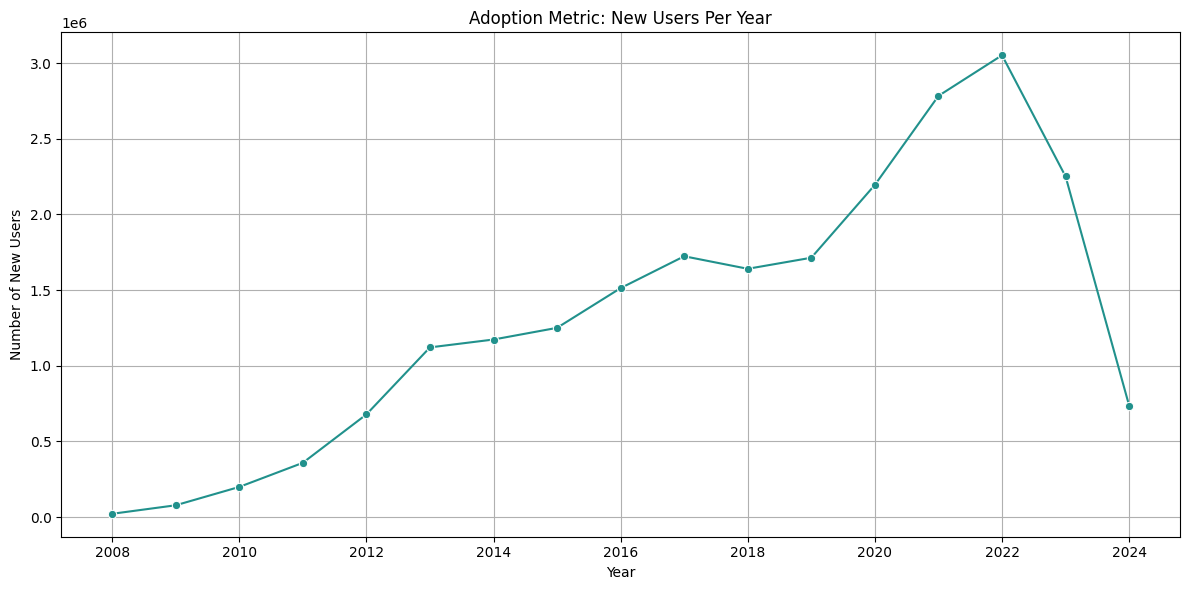

In [19]:
# # === STEP 7: Plot Adoption by Year with Viridis Palette ===
# plt.figure(figsize=(12, 6))

# # Use the viridis palette for a line (even though it's one line, it's still prettier this way)
# colors = sns.color_palette("viridis", n_colors=1)

# sns.lineplot(
#     data=yearly_users,
#     x="Year",
#     y="NewUsers",
#     marker="o",
#     color=colors[0]
# )

# plt.title("Adoption Metric: New Users Per Year")
# plt.xlabel("Year")
# plt.ylabel("Number of New Users")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

C:\Users\Ola\AppData\Local\Temp\ipykernel_1564\2836525341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="YearMonth", y="count", data=df, palette="viridis")
C:\Users\Ola\AppData\Local\Temp\ipykernel_1564\2836525341.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(year_month_pattern)


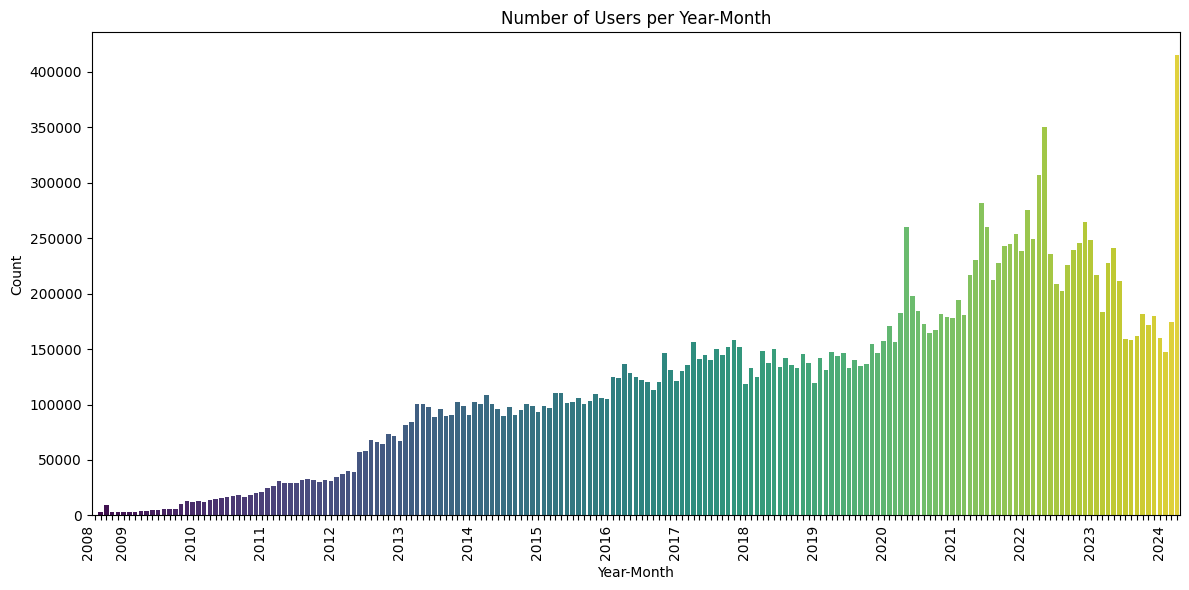

In [27]:
# === STEP 7: Create Bar Plot with Grouped Year Labels ===
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="YearMonth", y="count", data=df, palette="viridis")

plt.title("Number of Users per Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Count")
plt.xticks(rotation=90, ha='right')

# Create custom x-axis labels: one label per year, rest are spaces
year_month_pattern = []
unique_years = df["YearMonth"].str.split("-").str[0].unique()

for year in unique_years:
    year_month_pattern.append(year)
    year_month_pattern.extend([' '] * (df["YearMonth"].str.startswith(year).sum() - 1))

ax.set_xticklabels(year_month_pattern)

plt.tight_layout()
plt.show()

##  Retention Metric – What It Tells Us
### Retention shows how many users returned to the platform after signing up.

### You’re using Stack Overflow data, so we’ll measure this by comparing:

- CreationDate (when the user joined)
- LastAccessDate (when they last came back)

Retention Logic
1. Convert CreationDate and LastAccessDate to datetime (already done)

2. Calculate how many days the user was active:

In [28]:
users_df["DaysActive"] = (users_df["LastAccessDate"] - users_df["CreationDate"]).dt.days

3. Define “retained” users:
- A user is retained if they returned at least 7 days after signup:

In [30]:
users_df["Retained"] = users_df["DaysActive"] >= 7

4. Plot retention rate per signup month: 
What percentage of users each month were retained?

In [ ]:
# # Here are steps for Retention metric, some are identical to above Adopotion, hence commented out
# # === STEP 1: Import Libraries ===
# import pandas as pd
# import sqlite3
# import seaborn as sns
# import matplotlib.pyplot as plt
# from datetime import datetime

# # === STEP 2: Connect to the Database ===
# conn = sqlite3.connect("stackoverflow.db")

# # === STEP 3: Load and Preview 'users' Table ===
# users_df = pd.read_sql_query("SELECT * FROM users", conn)

# # === STEP 4: Data Cleaning ===
# users_df["CreationDate"] = pd.to_datetime(users_df["CreationDate"], errors="coerce")
# users_df["LastAccessDate"] = pd.to_datetime(users_df["LastAccessDate"], errors="coerce")
# users_df = users_df.dropna(subset=["CreationDate"])
# users_df = users_df.drop_duplicates(subset=["Id"])
# users_df = users_df[users_df["CreationDate"] <= pd.Timestamp(datetime.today())]

# # === STEP 5: Calculate Days Active and Retention Flag ===
# users_df["DaysActive"] = (users_df["LastAccessDate"] - users_df["CreationDate"]).dt.days
# users_df["Retained"] = users_df["DaysActive"] >= 7

In [31]:
# === STEP 6: Extract Year-Month from CreationDate ===
users_df["YearMonth"] = users_df["CreationDate"].dt.to_period("M").astype(str)

In [32]:
# === STEP 7: Calculate Retention Rate by Month ===
retention_stats = (
    users_df.groupby("YearMonth")["Retained"]
    .agg(["count", "sum"])
    .rename(columns={"count": "TotalUsers", "sum": "RetainedUsers"})
    .reset_index()
)
retention_stats["RetentionRate"] = (retention_stats["RetainedUsers"] / retention_stats["TotalUsers"]) * 100

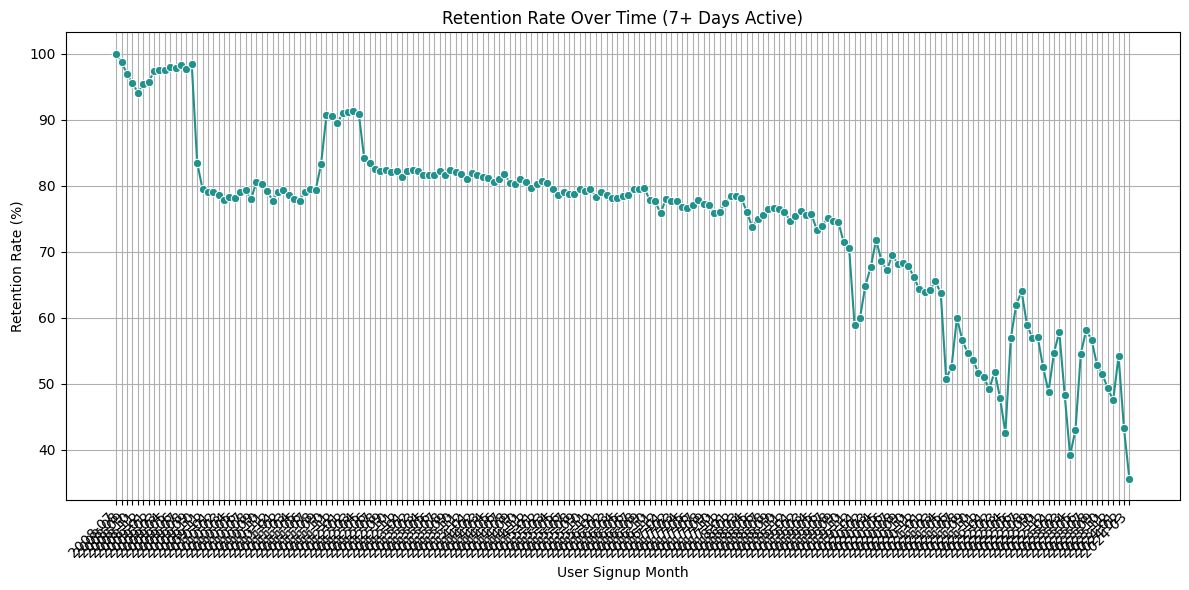

In [33]:
# === STEP 8: Plot Retention Rate Over Time ===
plt.figure(figsize=(12, 6))
sns.lineplot(data=retention_stats, x="YearMonth", y="RetentionRate", marker="o", color=sns.color_palette("viridis", 1)[0])
plt.title("Retention Rate Over Time (7+ Days Active)")
plt.xlabel("User Signup Month")
plt.ylabel("Retention Rate (%)")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\Ola\AppData\Local\Temp\ipykernel_1564\3686789504.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="YearMonth", y="RetentionRate", data=retention_stats, palette="viridis")
C:\Users\Ola\AppData\Local\Temp\ipykernel_1564\3686789504.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(year_month_pattern)


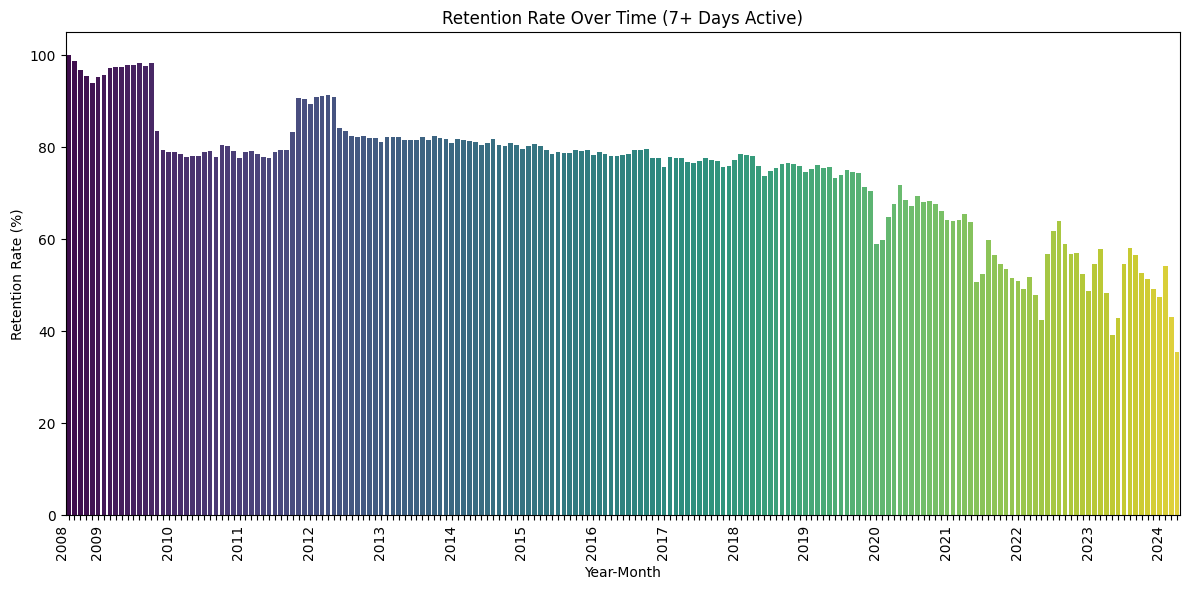

In [37]:
# === STEP 8 (Updated): Bar Plot for Retention with Grouped Year
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="YearMonth", y="RetentionRate", data=retention_stats, palette="viridis")

plt.title("Retention Rate Over Time (7+ Days Active)")
plt.xlabel("Year-Month")
plt.ylabel("Retention Rate (%)")
plt.xticks(rotation=90, ha='right')

# Create custom x-axis labels: one per year, rest are spaces
year_month_pattern = []
unique_years = retention_stats["YearMonth"].str.split("-").str[0].unique()

for year in unique_years:
    year_month_pattern.append(year)
    year_month_pattern.extend([' '] * (retention_stats["YearMonth"].str.startswith(year).sum() - 1))

ax.set_xticklabels(year_month_pattern)

plt.tight_layout()
plt.show()

In [ ]:
# # Releasing RAM during this session
# del df
# import gc
# gc.collect()
